In [115]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import RemoveMessage
from langchain_groq import ChatGroq

In [116]:
load_dotenv()
# llm = ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')
llm = ChatGroq(model="llama-3.1-8b-instant")

In [117]:
def chat_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    return {"messages": response}

In [118]:
def cleanup(state: MessagesState):
    msg = state['messages']

    if(len(msg) > 10):
        to_del = msg[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_del]}
    return {}

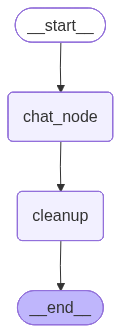

In [119]:
graph = StateGraph(MessagesState)

graph.add_node("chat_node", chat_node)
graph.add_node("cleanup", cleanup)


graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", "cleanup")

graph.add_edge("cleanup", END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

workflow

In [120]:

config = {"configurable": {"thread_id": "t1"}}

In [121]:
workflow.invoke({"messages": [{"role": "user", "content": "Hi, I'm Rathan"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Rathan", additional_kwargs={}, response_metadata={}, id='097a3157-5606-4107-a490-fade2e546ed0'),
  AIMessage(content="Hello Rathan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.027098679, 'completion_tokens_details': None, 'prompt_time': 0.002843085, 'prompt_tokens_details': None, 'queue_time': 0.045325705, 'total_time': 0.029941764}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d6b0c-2118-72f3-89db-340b0f2a1e55-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68})]}

In [122]:
workflow.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Rathan", additional_kwargs={}, response_metadata={}, id='097a3157-5606-4107-a490-fade2e546ed0'),
  AIMessage(content="Hello Rathan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.027098679, 'completion_tokens_details': None, 'prompt_time': 0.002843085, 'prompt_tokens_details': None, 'queue_time': 0.045325705, 'total_time': 0.029941764}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d6b0c-2118-72f3-89db-340b0f2a1e55-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_me

In [123]:
workflow.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Rathan", additional_kwargs={}, response_metadata={}, id='097a3157-5606-4107-a490-fade2e546ed0'),
  AIMessage(content="Hello Rathan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.027098679, 'completion_tokens_details': None, 'prompt_time': 0.002843085, 'prompt_tokens_details': None, 'queue_time': 0.045325705, 'total_time': 0.029941764}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d6b0c-2118-72f3-89db-340b0f2a1e55-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_me

In [124]:
# workflow.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

In [125]:
workflow.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Rathan", additional_kwargs={}, response_metadata={}, id='097a3157-5606-4107-a490-fade2e546ed0'),
  AIMessage(content="Hello Rathan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.027098679, 'completion_tokens_details': None, 'prompt_time': 0.002843085, 'prompt_tokens_details': None, 'queue_time': 0.045325705, 'total_time': 0.029941764}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d6b0c-2118-72f3-89db-340b0f2a1e55-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_me

In [126]:
workflow.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)

{'messages': [HumanMessage(content="Hi, I'm Rathan", additional_kwargs={}, response_metadata={}, id='097a3157-5606-4107-a490-fade2e546ed0'),
  AIMessage(content="Hello Rathan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.027098679, 'completion_tokens_details': None, 'prompt_time': 0.002843085, 'prompt_tokens_details': None, 'queue_time': 0.045325705, 'total_time': 0.029941764}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d6b0c-2118-72f3-89db-340b0f2a1e55-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68}),
  HumanMessage(content='Tell me about LangGraph', additional_kwargs={}, response_me

In [127]:
workflow.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='ed7a0c45-f13a-4101-91d9-9b538c995687'),
  AIMessage(content='LangChain is an open-source project that provides a framework for building large-scale language models and applications. It is designed to be a flexible and extensible platform for working with language models, allowing developers to build custom models, tools, and applications on top of LangChain.\n\n**Key Features of LangChain:**\n\n1. **Modular Architecture:** LangChain is built as a modular architecture, allowing developers to easily swap out or add new components as needed.\n2. **Language Model Integration:** LangChain provides a simple and consistent API for integrating a wide range of language models, including transformer-based models like BERT and RoBERTa.\n3. **Database Integration:** LangChain allows developers to easily integrate with various databases, including relational databases like MySQL and PostgreSQL, a

In [128]:
workflow.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='ed7a0c45-f13a-4101-91d9-9b538c995687'),
  AIMessage(content='LangChain is an open-source project that provides a framework for building large-scale language models and applications. It is designed to be a flexible and extensible platform for working with language models, allowing developers to build custom models, tools, and applications on top of LangChain.\n\n**Key Features of LangChain:**\n\n1. **Modular Architecture:** LangChain is built as a modular architecture, allowing developers to easily swap out or add new components as needed.\n2. **Language Model Integration:** LangChain provides a simple and consistent API for integrating a wide range of language models, including transformer-based models like BERT and RoBERTa.\n3. **Database Integration:** LangChain allows developers to easily integrate with various databases, including relational databases like MySQL and PostgreSQL, a